In [1]:
# Si no está sqlite3
#!pip install sqlite3

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

import sqlite3

# Introducción a SQL en Python con SQLite

Para simplicidad vamos a usar un servidor SQL virtual (no necesitamos usuarios, password, ni ninguna complicación).

In [3]:
# 1) Creamos una base de datos SQLite en memoria
con = sqlite3.connect(":memory:")

In [4]:
# Creamos una tabla de productos
# No estudiamos estos comandos, los usamos para tener una tabla dentro de la base de datos
setup_sql = """
DROP TABLE IF EXISTS productos;

CREATE TABLE productos (
  producto_id INTEGER PRIMARY KEY,
  titulo      TEXT NOT NULL,
  categoria   TEXT NOT NULL,
  precio      REAL NOT NULL
);

INSERT INTO productos(producto_id, titulo, categoria, precio) VALUES
(0,'El Principito', 'libro', 12.00),
(1,'El Declive', 'libro', 18.00),
(2,'go', 'juguete',  25.00),
(3,'ajedrez', 'juguete',  15.00),
(4,'fideos', 'comida',  5.00),
(5,'pan lactal', 'comida',  8.00);

"""

con.executescript(setup_sql)

## SELECT
El comando SELECT nos permite obtener datos de una tabla.

### Sytaxis 1

```
SELECT *
FROM table;
```

Nos da todos los datos de la tabla.

In [5]:
# Leemos toda la tabla

# En Pandas ejecutamos "queries" con read_sql_query(query string, conexión)
productos = pd.read_sql_query("SELECT * FROM productos;", con)
productos

,producto_id,titulo,categoria,precio
0,0,El Principito,libro,12.0
1,1,El Declive,libro,18.0
2,2,go,juguete,25.0
3,3,ajedrez,juguete,15.0
4,4,fideos,comida,5.0
5,5,pan lactal,comida,8.0


### Sytaxis 2

```
SELECT columna1, columna2, ...
FROM table;
```
Nos da solo las las columnas indicadas.

In [6]:
# Leemos las columnas titulo y precio
productos = pd.read_sql_query("SELECT titulo, precio FROM productos;", con)
productos

,titulo,precio
0,El Principito,12.0
1,El Declive,18.0
2,go,25.0
3,ajedrez,15.0
4,fideos,5.0
5,pan lactal,8.0


In [7]:
# OJO! Acá no van paréntesis (ni hace falta comillas para los nombres de columnas o tablas)
#productos = pd.read_sql_query("SELECT (titulo, precio) FROM productos;", con)
#productos

### Sytaxis 3

```
SELECT columna1, columna2, ...
FROM table
WHERE condiciones;
```
Nos da solo las las columnas indicadas que de las filas que cumplan las condiciones.

In [8]:
# Leemos las columnas titulo y precio de articulos que cuestan mas de 10 pesos
productos = pd.read_sql_query("SELECT titulo, precio FROM productos WHERE precio > 10;", con)
productos

,titulo,precio
0,El Principito,12.0
1,El Declive,18.0
2,go,25.0
3,ajedrez,15.0


In [9]:
# Si queremos los articulos con precio entre 10 y 20...
productos = pd.read_sql_query("SELECT titulo, precio FROM productos WHERE precio > 10 AND precio < 20;", con)
productos

,titulo,precio
0,El Principito,12.0
1,El Declive,18.0
2,ajedrez,15.0


In [10]:
# Acá sí podemos poner paréntesis si la condición es más compleja
# Usamos comillas simples para strings
productos = pd.read_sql_query("SELECT titulo, precio FROM productos WHERE (precio > 10) AND (categoria = 'juguete' OR categoria = 'libro');", con)
productos

,titulo,precio
0,El Principito,12.0
1,El Declive,18.0
2,go,25.0
3,ajedrez,15.0


## Ejercicio
Rehacemos algunos filtros de clases anteriores.
1. De la base Gapminder, seleccionar todas las filas del año 2007.
2. De la base Gapminder, seleccionar todas las filas de Argentina.
3. De la base MPG seleccionar las columnas mpg, horsepower y model_year de todos los modelos de los años 1970, 1975 y 1980.

Sugerencia para el último ítem
```
SELECT column1, column2, ...
FROM table_name
WHERE column_name IN (value1, value2, ...);
```

In [11]:
!pip install gapminder

In [12]:
# Cargamos los DataFrames
from gapminder import gapminder
mpg = sns.load_dataset("mpg")

In [13]:
# Para convertir un DataFrame a SQL:
conGap = sqlite3.connect(":memory:")   # Le damos otro nombre a la conexión, representa una conexión a otra base de datos.

# Guardar el DataFrame como tabla "gapminder"
gapminder.to_sql("gapminder", conGap, index=False, if_exists="replace")

1704

(devolvió la cantidad de filas afectadas)

In [14]:
# Verificamos (primeras filas)
pd.read_sql_query("SELECT * FROM gapminder LIMIT 5;", conGap)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


**Importante:** Esta forma de trabajar (primero cargar el DataFrame, pasarlo a SQL y despues volver a convertirlo a DataFrame) es claramente muy ineficiente. La utilizamos solo con fines **didácticos** para no montar un servidor SQL.

Tenemos que pensar que en el uso real, los datos ya van a estar en un servidor SQL.

In [16]:
# Seleccionamos los datos del año 2007
pd.read_sql_query("SELECT * FROM gapminder WHERE year = 2007;", conGap)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...,...
137,Vietnam,Asia,2007,74.249,85262356,2441.576404
138,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
139,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906
140,Zambia,Africa,2007,42.384,11746035,1271.211593


In [23]:
# Seleccionamos los datos de Argentina
pd.read_sql_query("SELECT * FROM gapminder WHERE country = 'Argentina';", conGap)

,country,continent,year,lifeExp,pop,gdpPercap
0,Argentina,Americas,1952,62.485,17876956,5911.315053
1,Argentina,Americas,1957,64.399,19610538,6856.856212
2,Argentina,Americas,1962,65.142,21283783,7133.166023
3,Argentina,Americas,1967,65.634,22934225,8052.953021
4,Argentina,Americas,1972,67.065,24779799,9443.038526
5,Argentina,Americas,1977,68.481,26983828,10079.026740
6,Argentina,Americas,1982,69.942,29341374,8997.897412
7,Argentina,Americas,1987,70.774,31620918,9139.671389
8,Argentina,Americas,1992,71.868,33958947,9308.418710
9,Argentina,Americas,1997,73.275,36203463,10967.281950


In [28]:
# columnas mpg, horsepower y model_year de todos los modelos de los años 1970, 1975 y 1980
conMPG = sqlite3.connect(":memory:")   # Le damos otro nombre a la conexión, representa una conexión a otra base de datos.
mpg.to_sql("mpg", conMPG, index=False, if_exists="replace")

398

In [32]:
pd.read_sql_query("SELECT * FROM mpg WHERE model_year IN (70, 75, 80);", conMPG)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
83,32.7,6,168.0,132.0,2910,11.4,80,japan,datsun 280-zx
84,23.7,3,70.0,100.0,2420,12.5,80,japan,mazda rx-7 gs
85,35.0,4,122.0,88.0,2500,15.1,80,europe,triumph tr7 coupe
86,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra


## Agregamos datos con GROUP BY
```
SELECT columnas_agrupacion, funcion_de_agregacion(columna)
FROM tabla
WHERE condicion
GROUP BY columna_agrupacion;
```

**Ejemplo.** Calcular la población total por continente en 2007 y graficar.

In [33]:
# 3 comillas para texto multi-linea
pd.read_sql_query("""
SELECT
    continent, year, SUM(pop)
FROM gapminder
WHERE year = 2007
GROUP BY continent
""", conGap)

,continent,year,SUM(pop)
0,Africa,2007,929539692
1,Americas,2007,898871184
2,Asia,2007,3811953827
3,Europe,2007,586098529
4,Oceania,2007,24549947


### Para renombrar la columna
```
SELECT columnas_agrupacion, funcion_de_agregacion(columna) as nombre_columna
FROM tabla
WHERE condicion
GROUP BY columna_agrupacion;
```

In [34]:
pd.read_sql_query("""
SELECT
    continent, year, SUM(pop) as poblacion_total
FROM gapminder
WHERE year = 2007
GROUP BY continent
""", conGap)

,continent,year,poblacion_total
0,Africa,2007,929539692
1,Americas,2007,898871184
2,Asia,2007,3811953827
3,Europe,2007,586098529
4,Oceania,2007,24549947


In [35]:
# Y si queremos la poblacion total en cada año?
# Funciona esto?
pob = pd.read_sql_query("""
SELECT
    continent,
    year,
    SUM(pop) as poblacion_total
FROM gapminder
GROUP BY continent
""", conGap)

In [36]:
pob

,continent,year,poblacion_total
0,Africa,1952,6187585961
1,Americas,1952,7351438499
2,Asia,1952,30507333901
3,Europe,1952,6181115304
4,Oceania,1952,212992136


In [39]:
# Cómo lo arreglamos?
pd.read_sql_query("""
SELECT
    year,
    SUM(pop) as poblacion_total
FROM gapminder
GROUP BY year
""", conGap)

,year,poblacion_total
0,1952,2406957150
1,1957,2664404580
2,1962,2899782974
3,1967,3217478384
4,1972,3576977158
5,1977,3930045807
6,1982,4289436840
7,1987,4691477418
8,1992,5110710260
9,1997,5515204472


### Ejercicio
Utilizando SQL generar una tabla con el total de pasajeros por año de la tabla de pasajes de avión y graficar.

In [40]:
flights = sns.load_dataset("flights")
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [41]:
conFlights = sqlite3.connect(":memory:")   # Le damos otro nombre a la conexión, representa una conexión a otra base de datos.
flights.to_sql("Flights", conFlights, index=False, if_exists="replace")

144

In [43]:
Passengers_year = pd.read_sql_query("""
SELECT
    year,
    SUM(passengers) as total_passengers
FROM Flights
GROUP BY year
""", conFlights)

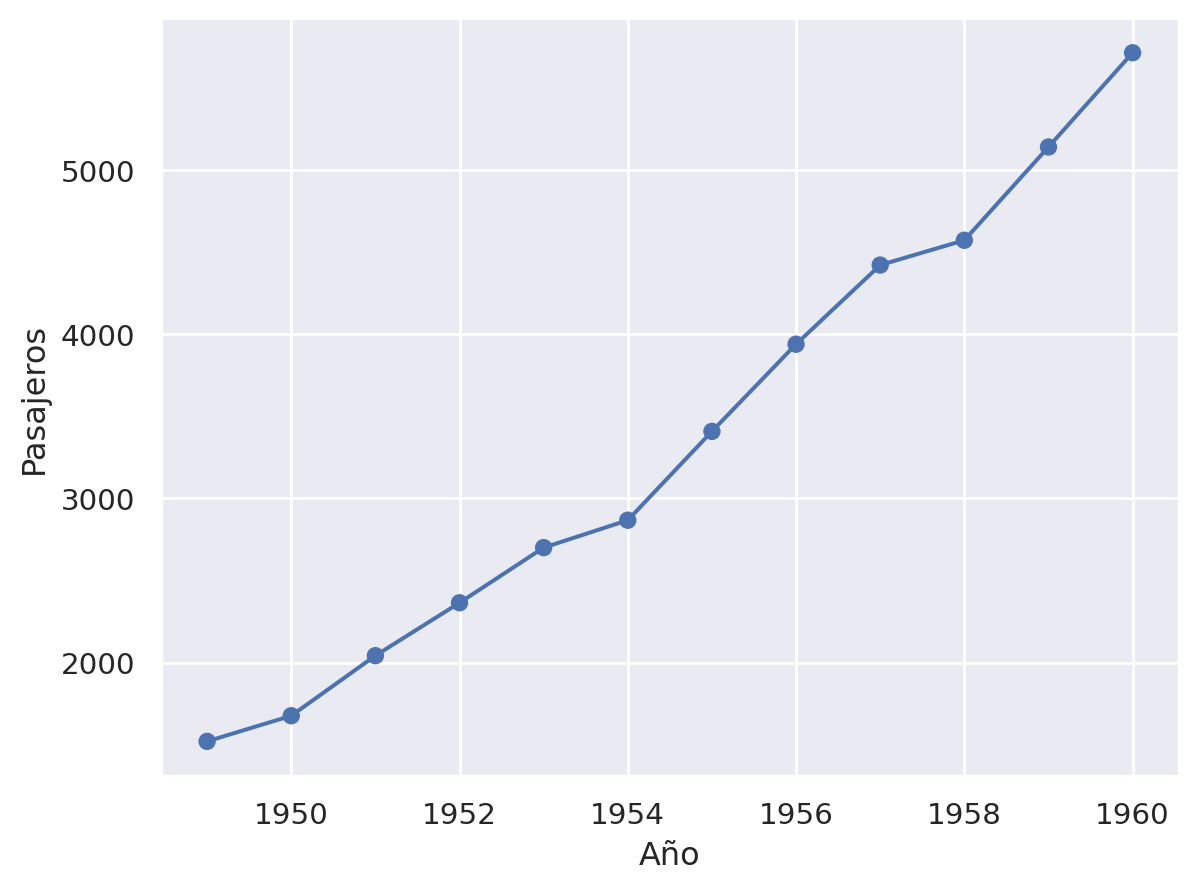

In [47]:
(
    so.Plot(data = Passengers_year, x = "year", y = "total_passengers")
    .add(so.Line())
    .add(so.Dot())
    .label(x = "Año", y = "Pasajeros")
)

### Ejercicio
1. Utilizando SQL generar una tabla con el peso promedio de los pingüinos por especie. Función: AVG(columna)
2. Utilizando SQL generar una tabla con el peso promedio de los pingüinos por especie e isla (es decir un valor para cada combinación de isla y especie).
3. Utilizando SQL generar una tabla con la cantidad de  pingüinos por especie e isla (es decir un valor para cada combinación de isla y especie en la que haya al menos un pingüino). Función: COUNT(*) (no contamos una columna en particular, sino filas)

In [49]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [50]:
conPenguins = sqlite3.connect(":memory:")
penguins.to_sql("Penguins", conPenguins, index=False, if_exists="replace")

344

In [53]:
pd.read_sql_query("""
SELECT
    species,
    AVG(body_mass_g) as peso_promedio_g
FROM Penguins
GROUP BY species
""", conPenguins)

,species,peso_promedio_g
0,Adelie,3700.662252
1,Chinstrap,3733.088235
2,Gentoo,5076.016260


In [57]:
pd.read_sql_query("""
SELECT
    island,
    species,
    AVG(body_mass_g) as peso_promedio_g
FROM Penguins
GROUP BY island, species
""", conPenguins)

,island,species,peso_promedio_g
0,Biscoe,Adelie,3709.659091
1,Biscoe,Gentoo,5076.016260
2,Dream,Adelie,3688.392857
3,Dream,Chinstrap,3733.088235
4,Torgersen,Adelie,3706.372549


In [58]:
pd.read_sql_query("""
SELECT
    island,
    species,
    COUNT(*) as cant_pinguinos
FROM Penguins
GROUP BY island, species
""", conPenguins)

,island,species,cant_pinguinos
0,Biscoe,Adelie,44
1,Biscoe,Gentoo,124
2,Dream,Adelie,56
3,Dream,Chinstrap,68
4,Torgersen,Adelie,52


# Más adelante...
Vamos a ver cómo combinar información en distintas tablas, donde vamos a ver mejor el potencial de SQL.